# Fragility Score investment evaluation

This notebook audits the supplementary investment-evaluation outputs created by `scripts/25_build_fragility_investment_evaluation.py`.

It examines:

1. the continuous performance of the fixed Decile 10 exclusion;
2. performance relative to the complete eligible universe and CRSP market;
3. the incremental return from screening; and
4. CAPM and Fama-French five-factor-plus-momentum alpha.

This analysis is supplementary. It does not change the primary downside-risk objective or model selection.

## 1. Fixed design

- The screened strategy excludes Fragility Score decile 10.
- The internal benchmark holds all eligible stocks under the same equal-weighting rule.
- Both portfolios rebalance on the first market day after each information cutoff and then hold until the next rebalance.
- The last signal is held for its fixed 63-market-day target window.
- CRSP total-market returns provide an external benchmark.
- CAPM and FF5-plus-momentum alphas use daily Kenneth French factors and five-lag HAC standard errors.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd


project_root = Path.cwd().resolve()
while not (project_root / "config" / "paths.yaml").is_file():
    if project_root.parent == project_root:
        raise RuntimeError("Could not locate the project root.")
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils.configuration import get_paths_config
from src.visualization.style import (
    apply_matplotlib_layout,
    set_matplotlib_style,
)

set_matplotlib_style()
paths = get_paths_config()
evaluation_directory = paths.tables / "evaluation"
files = {
    "daily strategy returns": evaluation_directory / "fragility_strategy_daily_returns.parquet",
    "strategy performance": evaluation_directory / "fragility_strategy_performance.csv",
    "factor alpha": evaluation_directory / "fragility_strategy_alpha.csv",
    "Fragility Score signals": evaluation_directory / "fragility_stock_quarters.parquet",
    "daily factors": paths.interim / "fama_french" / "daily_factors.parquet",
}

for description, path in files.items():
    if not path.is_file():
        raise FileNotFoundError(f"{description} not found: {path}")

In [2]:
daily = pd.read_parquet(files["daily strategy returns"])
performance = pd.read_csv(files["strategy performance"])
alpha = pd.read_csv(files["factor alpha"])
signals = pd.read_parquet(files["Fragility Score signals"], columns=["report_period"])
factors = pd.read_parquet(files["daily factors"], columns=["date"])

expected_strategies = {
    "all_stocks",
    "exclude_most_fragile_decile",
    "crsp_total_market",
}
expected_alpha_portfolios = {
    "all_stocks",
    "exclude_most_fragile_decile",
    "screened_minus_all_stocks",
}
expected_alpha_models = {"capm", "ff5_momentum"}
expected_alpha_rows = {
    (portfolio, model)
    for portfolio in expected_alpha_portfolios
    for model in expected_alpha_models
}

if daily.isna().any().any() or performance.isna().any().any() or alpha.isna().any().any():
    raise RuntimeError("Investment-evaluation outputs contain missing values.")
if not daily["date"].is_monotonic_increasing or daily["date"].duplicated().any():
    raise RuntimeError("Daily strategy dates must be ordered and unique.")
if set(daily["report_period"]) != set(signals["report_period"]):
    raise RuntimeError("Daily allocations do not cover every signal quarter.")
if not daily["date"].isin(factors["date"]).all():
    raise RuntimeError("Some strategy dates are missing from the factor data.")
if set(performance["strategy"]) != expected_strategies:
    raise RuntimeError("Unexpected strategy-performance rows.")
if set(zip(alpha["portfolio"], alpha["model"])) != expected_alpha_rows:
    raise RuntimeError("Unexpected factor-alpha rows.")
if not performance["trading_days"].eq(len(daily)).all():
    raise RuntimeError("Performance rows use inconsistent trading-day counts.")
if not alpha["trading_days"].eq(len(daily)).all():
    raise RuntimeError("Alpha rows use inconsistent trading-day counts.")
if not np.allclose(
    daily["active_return"],
    daily["screened_return"] - daily["all_stocks_return"],
):
    raise RuntimeError("Active returns do not equal screened minus all-stock returns.")

print(f"Trading days: {len(daily):,}")
print(f"Quarterly allocations: {daily['report_period'].nunique()}")
print(f"First trading day: {daily['date'].min():%Y-%m-%d}")
print(f"Last trading day: {daily['date'].max():%Y-%m-%d}")
print("Investment-evaluation checks: PASS")

Trading days: 502
Quarterly allocations: 8
First trading day: 2024-05-16
Last trading day: 2026-05-18
Investment-evaluation checks: PASS


In [3]:
rebalance_schedule = (
    daily.groupby("report_period", as_index=False)
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        trading_days=("date", "size"),
        all_stocks=("all_stocks_count", "first"),
        screened_stocks=("screened_stocks_count", "first"),
    )
)
display(rebalance_schedule)

,report_period,start_date,end_date,trading_days,all_stocks,screened_stocks
0,2024-03-31,2024-05-16,2024-08-14,62,4005,3604
1,2024-06-30,2024-08-15,2024-11-14,65,3946,3551
2,2024-09-30,2024-11-15,2025-02-14,61,3869,3482
3,2024-12-31,2025-02-18,2025-05-15,62,3819,3437
4,2025-03-31,2025-05-16,2025-08-14,62,3767,3390
5,2025-06-30,2025-08-15,2025-11-14,65,3733,3359
6,2025-09-30,2025-11-17,2026-02-17,62,3706,3335
7,2025-12-31,2026-02-18,2026-05-18,63,3666,3299


## 2. Gross performance

The internal comparison isolates the effect of the score filter. The CRSP total-market index is shown as an external reference but differs in universe and weighting.

In [4]:
display(
    performance.style.format(
        {
            "trading_days": "{:,.0f}",
            "cumulative_return": "{:.2%}",
            "annualized_return": "{:.2%}",
            "annualized_volatility": "{:.2%}",
            "sharpe_ratio": "{:.3f}",
            "maximum_drawdown": "{:.2%}",
            "downside_volatility": "{:.2%}",
        }
    )
)

,strategy,trading_days,cumulative_return,annualized_return,annualized_volatility,sharpe_ratio,maximum_drawdown,downside_volatility
0,all_stocks,502,16.17%,7.82%,20.37%,0.239,26.50%,14.14%
1,exclude_most_fragile_decile,502,30.13%,14.13%,19.52%,0.532,24.11%,13.30%
2,crsp_total_market,502,41.36%,18.98%,16.37%,0.854,19.11%,11.14%


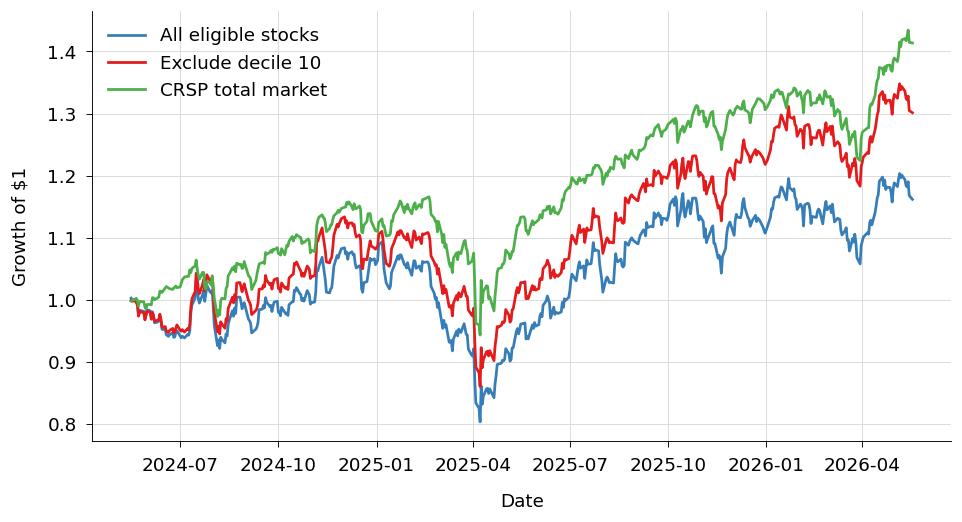

In [5]:
wealth = pd.DataFrame(
    {
        "All eligible stocks": (1 + daily["all_stocks_return"]).cumprod().to_numpy(),
        "Exclude decile 10": (1 + daily["screened_return"]).cumprod().to_numpy(),
        "CRSP total market": (1 + daily["crsp_market_return"]).cumprod().to_numpy(),
    },
    index=daily["date"],
)
fig, ax = plt.subplots(figsize=(9, 5))

for column in wealth:
    ax.plot(wealth.index, wealth[column], label=column)

ax.set(
    xlabel="Date",
    ylabel="Growth of $1",
)
ax.legend()
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_02_cumulative_performance.pdf")
plt.show()

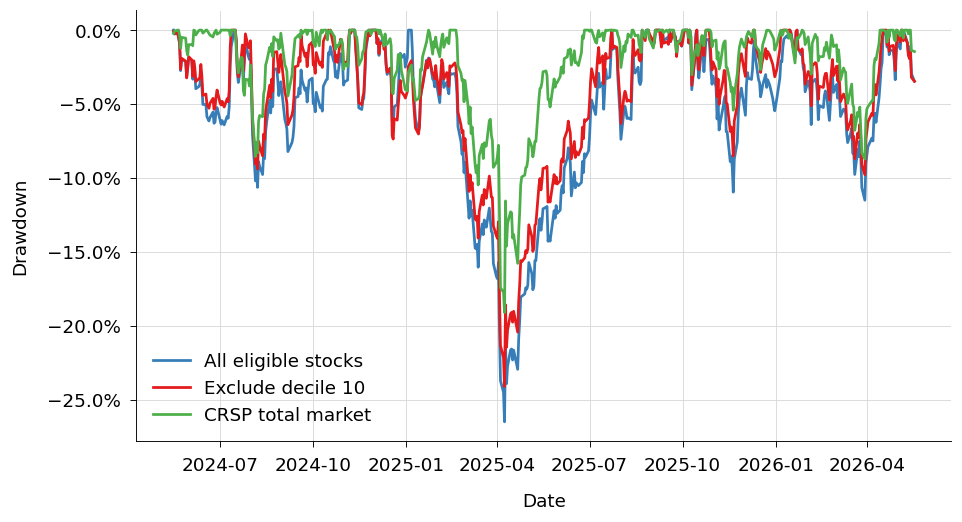

In [6]:
initial_wealth = pd.DataFrame(
    [np.ones(len(wealth.columns))],
    columns=wealth.columns,
)
wealth_with_initial = pd.concat(
    [initial_wealth, wealth.reset_index(drop=True)],
    ignore_index=True,
)
drawdown = wealth_with_initial / wealth_with_initial.cummax() - 1
drawdown = drawdown.iloc[1:].set_axis(daily["date"])
fig, ax = plt.subplots(figsize=(9, 5))

for column in drawdown:
    ax.plot(drawdown.index, drawdown[column], label=column)

ax.set(
    xlabel="Date",
    ylabel="Drawdown",
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_02_continuous_drawdowns.pdf")
plt.show()

## 3. Performance relative to the internal benchmark

Active return is the screened-strategy return minus the return on all eligible stocks. It measures the incremental contribution of removing decile 10.

Annualized mean active return: 5.53%
Tracking error: 2.70%
Information ratio: 2.045
Ending relative wealth gain: 12.01%


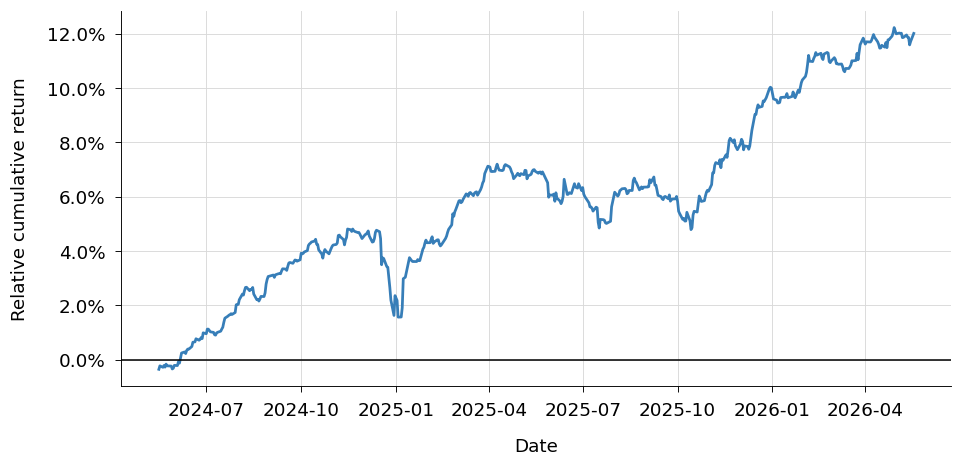

In [7]:
active_return = daily["active_return"]
tracking_error = active_return.std(ddof=1) * np.sqrt(252)
information_ratio = (
    np.sqrt(252) * active_return.mean() / active_return.std(ddof=1)
)
relative_wealth = wealth["Exclude decile 10"] / wealth["All eligible stocks"]

print(f"Annualized mean active return: {252 * active_return.mean():.2%}")
print(f"Tracking error: {tracking_error:.2%}")
print(f"Information ratio: {information_ratio:.3f}")
print(f"Ending relative wealth gain: {relative_wealth.iloc[-1] - 1:.2%}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(relative_wealth.index, relative_wealth - 1)
ax.axhline(0, color="black", linewidth=1)
ax.set(
    xlabel="Date",
    ylabel="Relative cumulative return",
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_02_relative_performance.pdf")
plt.show()

## 4. Factor-adjusted alpha

Standalone strategy returns are measured in excess of the daily risk-free rate. The active portfolio is zero-cost, so its dependent return is the screened return minus the all-stock return. Reported inference uses five-lag HAC standard errors.

In [8]:
alpha_display = alpha.copy()
display(
    alpha_display.style.format(
        {
            "trading_days": "{:,.0f}",
            "daily_alpha": "{:.4%}",
            "annualized_alpha": "{:.2%}",
            "alpha_standard_error": "{:.4%}",
            "alpha_t_statistic": "{:.3f}",
            "alpha_p_value": "{:.4f}",
            "adjusted_r_squared": "{:.3f}",
            "market_beta": "{:.3f}",
        }
    )
)

,portfolio,model,trading_days,daily_alpha,annualized_alpha,alpha_standard_error,alpha_t_statistic,alpha_p_value,adjusted_r_squared,market_beta
0,all_stocks,capm,502,-0.0400%,-10.08%,0.0340%,-1.176,0.2396,0.700,1.012
1,all_stocks,ff5_momentum,502,-0.0206%,-5.20%,0.0153%,-1.345,0.1786,0.946,0.838
2,exclude_most_fragile_decile,capm,502,-0.0166%,-4.19%,0.0307%,-0.541,0.5882,0.726,0.988
3,exclude_most_fragile_decile,ff5_momentum,502,0.0011%,0.27%,0.0097%,0.110,0.9123,0.975,0.849
4,screened_minus_all_stocks,capm,502,0.0233%,5.88%,0.0086%,2.701,0.0069,0.021,-0.024
5,screened_minus_all_stocks,ff5_momentum,502,0.0217%,5.47%,0.0078%,2.795,0.0052,0.159,0.011


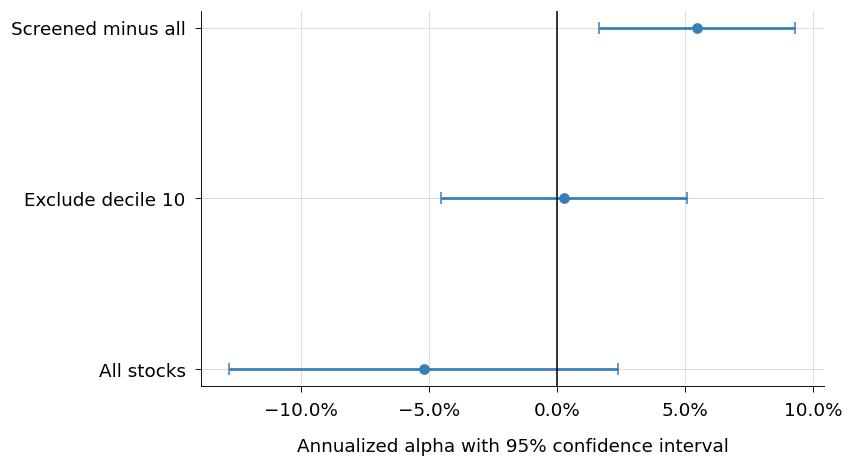

In [9]:
factor_alpha = alpha.loc[alpha["model"] == "ff5_momentum"].copy()
factor_alpha["label"] = factor_alpha["portfolio"].map(
    {
        "all_stocks": "All stocks",
        "exclude_most_fragile_decile": "Exclude decile 10",
        "screened_minus_all_stocks": "Screened minus all",
    }
)
factor_alpha["annualized_standard_error"] = (
    252 * factor_alpha["alpha_standard_error"]
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(
    factor_alpha["annualized_alpha"],
    factor_alpha["label"],
    xerr=1.96 * factor_alpha["annualized_standard_error"],
    fmt="o",
    capsize=4,
)
ax.axvline(0, color="black", linewidth=1)
ax.set(
    xlabel="Annualized alpha with 95% confidence interval",
)
ax.xaxis.set_major_formatter(PercentFormatter(1))
apply_matplotlib_layout(fig)
fig.savefig(paths.figures / "05_02_factor_alpha.pdf")
plt.show()

## 5. Interpretation

The Fragility Score filter improves performance relative to its controlled internal benchmark. Over 502 trading days, the screened strategy earns 29.83% cumulatively versus 16.17% for all eligible stocks. Its annualized return is 14.00% rather than 7.82%, while annualized volatility falls from 20.37% to 19.51% and maximum drawdown falls from 26.50% to 24.11%.

The incremental return is not equivalent to standalone market alpha. The screened strategy's FF5-plus-momentum alpha is approximately zero (0.12% annualized, p = 0.960), while the screened-minus-all active portfolio has a positive 5.32% annualized alpha (p = 0.0046). This indicates that the filter improves the risk-adjusted performance of the thesis universe mainly by removing its most fragile component; it does not establish that the resulting long-only strategy earns abnormal returns.
The CRSP total-market benchmark performs better than either thesis portfolio, with a 18.98% annualized return, 16.37% volatility, a 0.854 Sharpe ratio, and a 19.11% maximum drawdown. The screened strategy therefore does not dominate the broad market.

These results are supplementary and exploratory. They cover only eight quarterly allocation decisions, 502 daily returns, no transaction costs, and one test period. The evidence supports the Fragility Score as a useful filter within the eligible universe, but not as proof of a standalone alpha-generating strategy.